In [12]:
import pandas as pd

ama = pd.read_excel(r"C:\Users\Normc\OneDrive\Рабочий стол\Python\Работа\amocrm_export_leads_2026-02-13.xlsx")
onec = pd.read_excel(r"C:\Users\Normc\OneDrive\Рабочий стол\Python\Работа\Ю-АР-СИ.XLSX")
onec = onec[onec['Ответственный'] == 'Яшихин Алексей Валерьевич']

In [13]:
ama['Дата создания AMA'] = pd.to_datetime(ama['Дата создания'], dayfirst=True)
onec['Дата закрытия 1C'] = pd.to_datetime(onec['Дата выезда'], dayfirst=True)
onec['Дата создания 1C'] = pd.to_datetime(onec['Дата'], dayfirst=True)

ЕСли заказ создан в 1С, а в AMA на следующий день (24ч)

In [ ]:
merged = ama.merge(onec, how='cross')
merged['weekday'] = merged['Дата создания AMA'].dt.weekday
merged['Начало 1С - Начало AMA (ч)'] = round((merged['Дата создания 1C'] - merged['Дата создания AMA']).dt.total_seconds() / 3600, 2)
merged['Начало AMA - Начало 1C (ч)'] = round((merged['Дата создания AMA'] - merged['Дата создания 1C']).dt.total_seconds() / 3600, 2)

result = merged[
    ((merged['weekday'] <= 4) & (merged['Начало 1С - Начало AMA (ч)'] <= 72) & (merged['Начало 1С - Начало AMA (ч)'] >= 0)) | 
    ((merged['weekday'] == 5) & (merged['Начало 1С - Начало AMA (ч)'] <= 120) & (merged['Начало 1С - Начало AMA (ч)'] >= 0)) |
    ((merged['weekday'] <= 5) & (merged['Начало AMA - Начало 1C (ч)'] <= 24) & (merged['Начало 1С - Начало AMA (ч)'] >= 0))

]


result['Конец 1C - Начало 1C (ч)'] = round((result['Дата закрытия 1C'] - result['Дата создания 1C']).dt.total_seconds() / 3600, 2)

ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

In [19]:
result.loc[:,['Номер', 'Дата создания AMA', 'Дата создания 1C', 'Начало 1С - Начало AMA (ч)', 'Начало AMA - Начало 1C (ч)', 'Конец 1C - Начало 1C (ч)', 'Лот_y']]

,Номер,Дата создания AMA,Дата создания 1C,Начало 1С - Начало AMA (ч),Начало AMA - Начало 1C (ч),Конец 1C - Начало 1C (ч),Лот_y
73,БТС00002755,2026-02-10 22:49:36,2026-02-11 15:32:55,16.72,-16.72,NaN,E 04743
74,БТС00002758,2026-02-10 22:49:36,2026-02-11 15:42:25,16.88,-16.88,NaN,E 04740
146,БТС00002596,2026-02-05 10:01:56,2026-02-10 11:55:19,121.89,-121.89,NaN,B 01104
147,БТС00002601,2026-02-05 10:01:56,2026-02-10 12:07:34,122.09,-122.09,NaN,B 01610
148,БТС00002755,2026-02-05 10:01:56,2026-02-11 15:32:55,149.52,-149.52,NaN,E 04743
...,...,...,...,...,...,...,...
4420,БТС00002219,2025-08-21 14:32:35,2026-02-05 09:41:43,4027.15,-4027.15,-57.7,B 01559
4421,БТС00002596,2025-08-21 14:32:35,2026-02-10 11:55:19,4149.38,-4149.38,NaN,B 01104
4422,БТС00002601,2025-08-21 14:32:35,2026-02-10 12:07:34,4149.58,-4149.58,NaN,B 01610
4423,БТС00002755,2025-08-21 14:32:35,2026-02-11 15:32:55,4177.01,-4177.01,NaN,E 04743


In [20]:
result = result.loc[result['Конец 1C - Начало 1C (ч)'] >= 0,
           ['Номер', 'Дата создания AMA', 'Дата создания 1C', 
            'Дата закрытия 1C', 'Начало 1С - Начало AMA (ч)', 'Начало AMA - Начало 1C (ч)', 'Конец 1C - Начало 1C (ч)', 'VIN_Х. (ПР)', 'Лот_y']]

In [21]:
result

,Номер,Дата создания AMA,Дата создания 1C,Дата закрытия 1C,Начало 1С - Начало AMA (ч),Начало AMA - Начало 1C (ч),Конец 1C - Начало 1C (ч),VIN_Х. (ПР),Лот_y
288,БТС00001770,2026-01-30 13:15:52,2026-01-30 16:11:49,2026-02-04,2.93,-2.93,103.80,E 04740,B 01562
291,БТС00001881,2026-01-30 13:15:52,2026-02-02 14:57:52,2026-02-03,73.70,-73.70,9.04,E 04740,B 01562
363,БТС00001770,2026-01-30 12:07:12,2026-01-30 16:11:49,2026-02-04,4.08,-4.08,103.80,B 01361,B 01562
366,БТС00001881,2026-01-30 12:07:12,2026-02-02 14:57:52,2026-02-03,74.84,-74.84,9.04,B 01361,B 01562
438,БТС00001770,2026-01-29 16:43:32,2026-01-30 16:11:49,2026-02-04,23.47,-23.47,103.80,B 01562,B 01562
...,...,...,...,...,...,...,...,...,...
4406,БТС00000789,2025-08-21 14:32:35,2026-01-19 14:39:46,2026-01-21,3624.12,-3624.12,33.34,B 02106,B 01104
4408,БТС00001176,2025-08-21 14:32:35,2026-01-23 12:21:14,2026-02-04,3717.81,-3717.81,275.65,B 02106,B 04628
4410,БТС00001321,2025-08-21 14:32:35,2026-01-26 14:35:26,2026-01-27,3792.05,-3792.05,9.41,B 02106,B 04628
4413,БТС00001770,2025-08-21 14:32:35,2026-01-30 16:11:49,2026-02-04,3889.65,-3889.65,103.80,B 02106,B 01562


In [22]:
df = result[result['Лот_y'] == result['VIN_Х. (ПР)']]
df_all = df.sort_values(by='Дата создания AMA', ascending=True)
display(df_all)
df_all.shape[0]

,Номер,Дата создания AMA,Дата создания 1C,Дата закрытия 1C,Начало 1С - Начало AMA (ч),Начало AMA - Начало 1C (ч),Конец 1C - Начало 1C (ч),VIN_Х. (ПР),Лот_y
4382,БТС00019266,2025-08-21 14:32:35,2025-11-25 17:00:14,2025-11-26,2306.46,-2306.46,7.00,B 02106,B 02106
4350,БТС00012300,2025-08-21 14:32:35,2025-08-21 17:48:25,2025-08-25,3.26,-3.26,78.19,B 02106,B 02106
4356,БТС00014103,2025-08-21 14:32:35,2025-09-17 12:07:21,2025-09-23,645.58,-645.58,131.88,B 02106,B 02106
4373,БТС00018100,2025-08-21 14:32:35,2025-11-12 08:17:58,2025-11-14,1985.76,-1985.76,39.70,B 02106,B 02106
4362,БТС00017023,2025-08-21 14:32:35,2025-10-27 10:17:12,2025-10-29,1603.74,-1603.74,37.71,B 02106,B 02106
...,...,...,...,...,...,...,...,...,...
1771,БТС00000113,2026-01-12 11:39:34,2026-01-12 12:22:37,2026-01-14,0.72,-0.72,35.62,B 01558,B 01558
1702,БТС00000768,2026-01-19 08:25:13,2026-01-19 12:55:14,2026-01-21,4.50,-4.50,35.08,B 01361,B 01361
1481,БТС00000789,2026-01-19 14:04:46,2026-01-19 14:39:46,2026-01-21,0.58,-0.58,33.34,B 01104,B 01104
441,БТС00001881,2026-01-29 16:43:32,2026-02-02 14:57:52,2026-02-03,94.24,-94.24,9.04,B 01562,B 01562


104

In [ ]:
df_all[df_all['']]

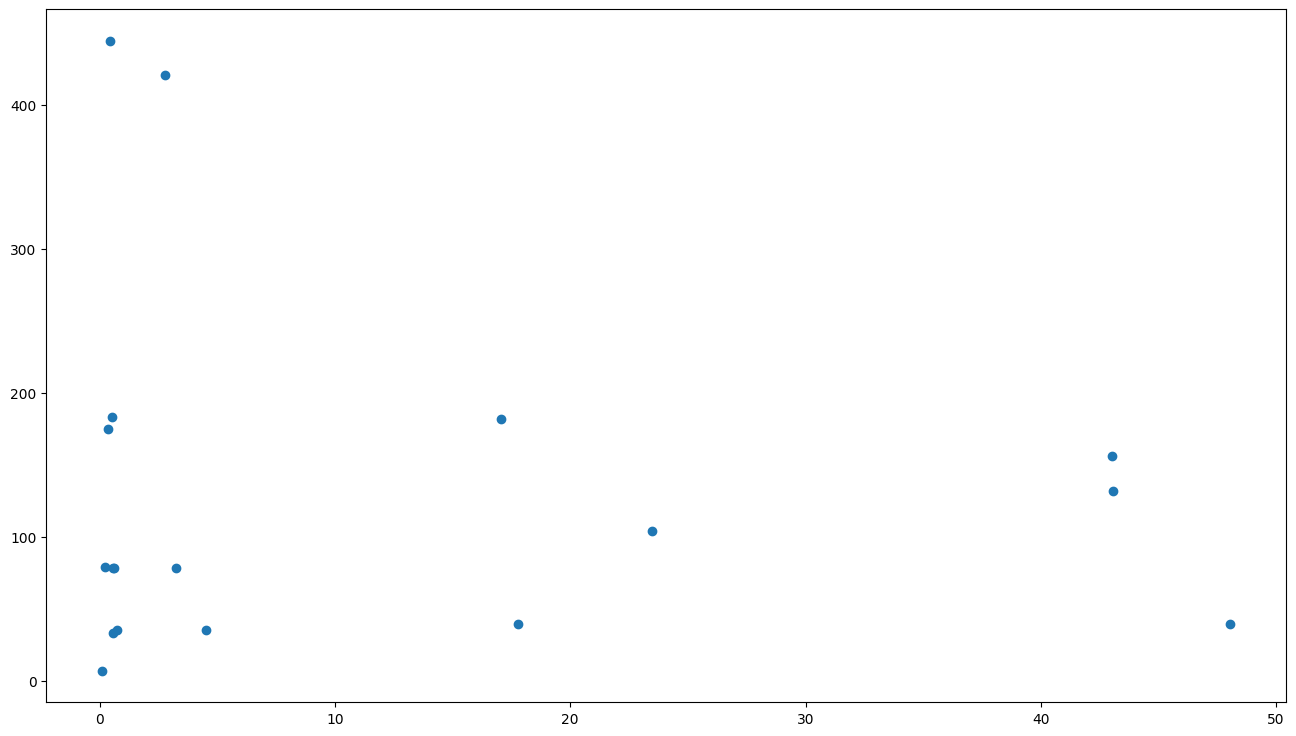

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 9))
plt.scatter(df_all['Начало 1С - Начало AMA (ч)'], df_all['Конец 1C - Начало 1C (ч)'])

In [11]:
df_all.to_excel('result_new.xlsx')